In [56]:
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.cluster import AgglomerativeClustering

In [57]:
ppd = pd.read_csv('preprocessed_movie_data.csv')
ppd2 = pd.read_csv('preprocessed_movie_data2.csv')

In [58]:
# Create a pipeline for preprocessing
pipeline = Pipeline(
    [
    ('impute',SimpleImputer(strategy='constant',fill_value=1)),
    ('scale',StandardScaler()),
    ('pca', PCA(n_components=3,random_state=42)),
    ]
)


In [59]:
# Fit the pipeline to the ppd data
# Drop unnecessary columns if they exist
columns_to_drop = ['movieId', 'title', 'Unnamed: 0']
X = ppd.drop(columns=[col for col in columns_to_drop if col in ppd.columns])
X_transformed = pipeline.fit_transform(X)
# Perform clustering
clustering = AgglomerativeClustering(n_clusters=5)
clusters = clustering.fit_predict(X_transformed)

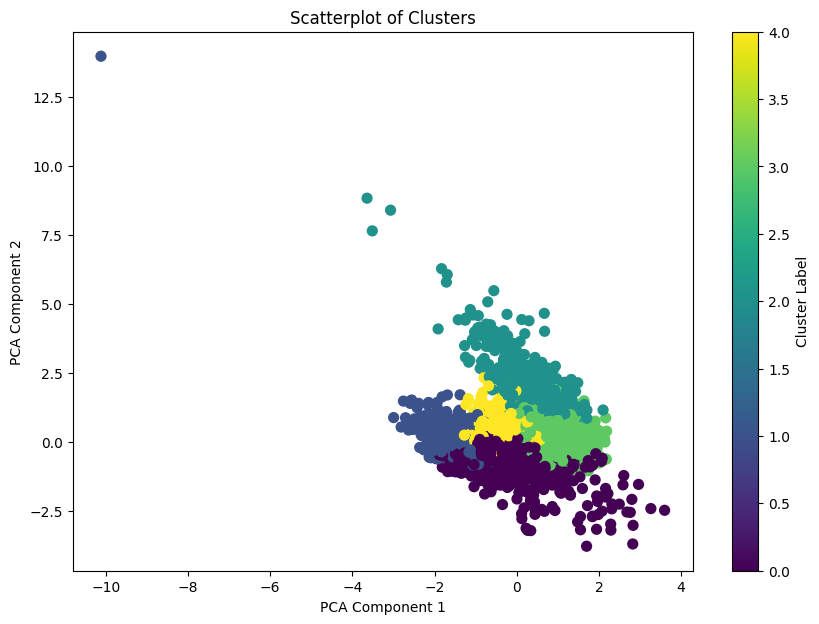

In [60]:
# Create Scatterplot for ppd data

plt.figure(figsize=(10, 7))
plt.scatter(X_transformed[:, 0], X_transformed[:, 1], c=clusters, cmap='viridis', s=50)
plt.title('Scatterplot of Clusters')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.colorbar(label='Cluster Label')  # Optional: if you want a color bar for reference
plt.show()

In [61]:
# Fit the pipeline to the ppd2 data
# Drop unnecessary columns if they exist
columns_to_drop2 = ['movieId', 'title', 'Unnamed: 0']
X2 = ppd2.drop(columns=[col for col in columns_to_drop2 if col in ppd2.columns])
# Adjust PCA to match the number of features in ppd2
pipeline.steps[-1] = ('pca', PCA(n_components=2, random_state=42))
X_transformed2 = pipeline.fit_transform(X2)
# Perform clustering
clustering2 = AgglomerativeClustering(n_clusters=5)
clusters2 = clustering.fit_predict(X_transformed2)

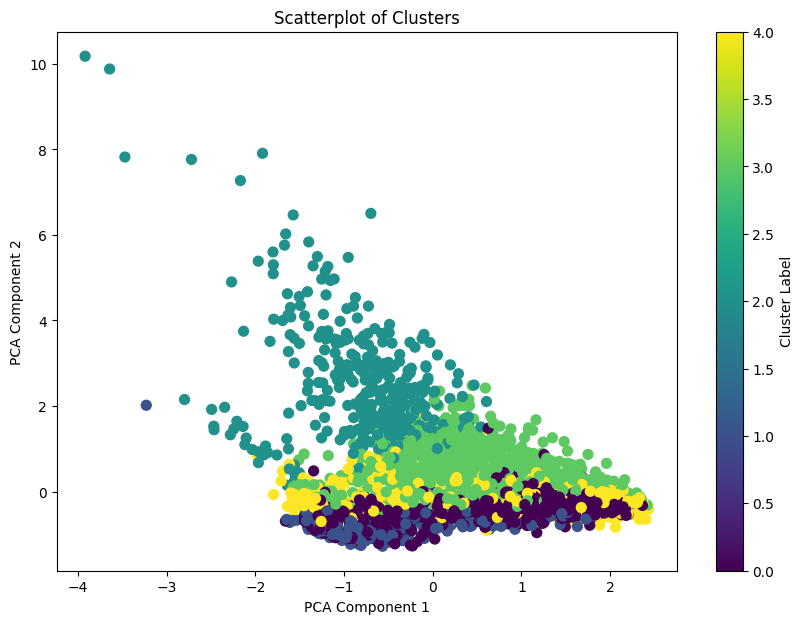

In [62]:
# Create Scatterplot for ppd2

plt.figure(figsize=(10, 7))
plt.scatter(X_transformed2[:, 0], X_transformed2[:, 1], c=clusters, cmap='viridis', s=50)
plt.title('Scatterplot of Clusters')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.colorbar(label='Cluster Label')  # Optional: if you want a color bar for reference
plt.show()

In [64]:
# Create labels for the clusters
labels = ['Cluster 1', 'Cluster 2', 'Cluster 3', 'Cluster 4', 'Cluster 5']
# Create a DataFrame to hold the cluster labels
cluster_labels = pd.DataFrame({'title': ppd['title'], 'Cluster': clusters})
# Merge the cluster labels with the original DataFrame
merged_df = pd.merge(ppd, cluster_labels, on='title')

In [65]:
merged_df

,title,PC1,PC2,PC3,PC4,PC5,PC6,PC7,Cluster
0,Kate & Leopold (2001),0.365811,1.674679,0.697536,-0.867474,0.614986,-0.760826,-0.510062,3
1,The Sorcerer's Apprentice (2010),0.334949,0.253406,-2.369158,-0.666094,0.655086,-0.872105,0.037816,3
2,Fantastic Four (2005),2.526709,0.662646,-0.605463,-1.021418,0.427681,-0.646847,0.422886,3
3,Fantastic Four (2015),0.987338,-0.072774,-0.460300,0.127163,-0.002844,-0.730169,1.113554,3
4,Frida (2002),0.075308,0.845189,1.396535,-0.896946,0.162305,-0.574121,-0.671469,3
...,...,...,...,...,...,...,...,...,...
4652,The Asadas (2020),-1.136747,-1.976078,0.795535,0.776484,-0.375664,-0.515400,-0.369464,0
4653,Caught in Time (2020),-0.588399,-1.671850,-1.142717,0.411517,-0.554540,-1.582273,-0.081351,3
4654,Malang (2020),-1.393844,-1.922148,0.551073,0.809941,0.373365,-0.083533,0.048234,4
4655,Moonage Daydream (2022),-0.910854,-0.613656,1.329126,1.638163,-0.272824,0.394038,-0.359412,0


NameError: name 'merged_df' is not defined